# Team STAR - Step 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tsim
import pymatching

We implement the physical_angle function given in the challenge instructions.

In [3]:
def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    """
    Compute the physical rotation angle needed to achieve a logical rotation of
    angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

    Args:
        logical_angle_in_pi (float): The logical rotation angle in units of pi.
        num_physical_rotations (int): The number of physical rotations that are applied.
    Returns:
        float: The physical rotation angle in units of pi.
    """

    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)


Circuit 3 template based on the file star_d=3.stim

In [4]:
circuit_3_template = """
QUBIT_COORDS(0.5, 0.5) 0
QUBIT_COORDS(1.5, 0.5) 1
QUBIT_COORDS(2.5, 0.5) 2
QUBIT_COORDS(0.5, 1.5) 3
QUBIT_COORDS(1.5, 1.5) 4
QUBIT_COORDS(2.5, 1.5) 5
QUBIT_COORDS(0.5, 2.5) 6
QUBIT_COORDS(1.5, 2.5) 7
QUBIT_COORDS(2.5, 2.5) 8
QUBIT_COORDS(1, 0) 9
QUBIT_COORDS(2, 1) 10
QUBIT_COORDS(1, 2) 11
QUBIT_COORDS(2, 3) 12
QUBIT_COORDS(1, 1) 13
QUBIT_COORDS(3, 1) 14
QUBIT_COORDS(0, 2) 15
QUBIT_COORDS(2, 2) 16
R 9 10 11 12
DEPOLARIZE1(0.001) 9 10 11 12
RX 0 1 2 3 4 5 6 7 8
DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8
TICK
CX 1 10 3 11 7 12
DEPOLARIZE2(0.001) 1 10 3 11 7 12
DEPOLARIZE1(0.001) 0 2 4 5 6 8 9 13 14 15 16
TICK
CX 2 10 4 11 8 12
DEPOLARIZE2(0.001) 2 10 4 11 8 12
DEPOLARIZE1(0.001) 0 1 3 5 6 7 9 13 14 15 16
TICK
CX 0 9 4 10 6 11
DEPOLARIZE2(0.001) 0 9 4 10 6 11
DEPOLARIZE1(0.001) 1 2 3 5 7 8 12 13 14 15 16
TICK
CX 1 9 5 10 7 11
DEPOLARIZE2(0.001) 1 9 5 10 7 11
DEPOLARIZE1(0.001) 0 2 3 4 6 8 12 13 14 15 16
TICK
DEPOLARIZE1(0.001) 9 10 11 12
M 9 10 11 12
DEPOLARIZE1(0.001)
MX
TICK
R 9 10 11 12
DEPOLARIZE1(0.001) 9 10 11 12
RX 13 14 15 16
DEPOLARIZE1(0.001) 13 14 15 16
TICK
CX 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE2(0.001) 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE1(0.001) 5 6 8 9 15
TICK
CX 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE2(0.001) 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE1(0.001) 0 1 6 9 15
TICK
CX 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE2(0.001) 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE1(0.001) 2 7 8 12 14
TICK
CX 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE2(0.001) 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE1(0.001) 0 2 3 12 14
TICK
DEPOLARIZE1(0.001) 9 10 11 12
M 9 10 11 12
DEPOLARIZE1(0.001) 13 14 15 16
MX 13 14 15 16
TICK
# First round of detectors
DETECTOR(1, 0, 0) rec[-8] rec[-12]
DETECTOR(2, 1, 0) rec[-7] rec[-11]
DETECTOR(1, 2, 0) rec[-6] rec[-10]
DETECTOR(2, 3, 0) rec[-5] rec[-9]
DETECTOR(1, 1, 0) rec[-4]
DETECTOR(3, 1, 0) rec[-3]
DETECTOR(0, 2, 0) rec[-2]
DETECTOR(2, 2, 0) rec[-1]
TICK
CX[FEED_FORWARD] rec[-8] 0 rec[-7] 0 rec[-7] 1 rec[-6] 3 rec[-5] 6 rec[-5] 7
DEPOLARIZE1(0.001) 0 1 3 6 7 2 4 5 8 9 10 11 12 13 14 15 16
TICK
# These are the physical rotation gates (3 for the d=3 code). You need to adjust the angles and the corresponding logial rotation at the end of this file
R_Z({theta_str}) 0 3 6  
DEPOLARIZE1(0.001) 0 3 6 1 2 4 5 7 8 9 10 11 12 13 14 15 16
TICK
R 9 10 11 12
DEPOLARIZE1(0.001) 9 10 11 12
RX 13 14 15 16
DEPOLARIZE1(0.001) 13 14 15 16
TICK
CX 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE2(0.001) 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE1(0.001) 5 6 8 9 15
TICK
CX 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE2(0.001) 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE1(0.001) 0 1 6 9 15
TICK
CX 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE2(0.001) 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE1(0.001) 2 7 8 12 14
TICK
CX 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE2(0.001) 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE1(0.001) 0 2 3 12 14
TICK
DEPOLARIZE1(0.001) 9 10 11 12
M 9 10 11 12
DEPOLARIZE1(0.001) 13 14 15 16
MX 13 14 15 16
TICK
# Second round of detectors
DETECTOR(1, 0, 1) rec[-8]
DETECTOR(2, 1, 1) rec[-7]
DETECTOR(1, 2, 1) rec[-6]
DETECTOR(2, 3, 1) rec[-5]
DETECTOR(1, 1, 1) rec[-4] rec[-12]
DETECTOR(3, 1, 1) rec[-3] rec[-11]
DETECTOR(0, 2, 1) rec[-2] rec[-10]
DETECTOR(2, 2, 1) rec[-1] rec[-9]
TICK
R 9 10 11 12
DEPOLARIZE1(0.001) 9 10 11 12
RX 13 14 15 16
DEPOLARIZE1(0.001) 13 14 15 16
TICK
CX 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE2(0.001) 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE1(0.001) 5 6 8 9 15
TICK
CX 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE2(0.001) 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE1(0.001) 0 1 6 9 15
TICK
CX 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE2(0.001) 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE1(0.001) 2 7 8 12 14
TICK
CX 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE2(0.001) 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE1(0.001) 0 2 3 12 14
TICK
DEPOLARIZE1(0.001) 9 10 11 12
M 9 10 11 12
DEPOLARIZE1(0.001) 13 14 15 16
MX 13 14 15 16
TICK

# Third round of detectors
DETECTOR(1, 0, 2) rec[-8] rec[-16]
DETECTOR(2, 1, 2) rec[-7] rec[-15]
DETECTOR(1, 2, 2) rec[-6] rec[-14]
DETECTOR(2, 3, 2) rec[-5] rec[-13]
DETECTOR(1, 1, 2) rec[-4] rec[-12]
DETECTOR(3, 1, 2) rec[-3] rec[-11]
DETECTOR(0, 2, 2) rec[-2] rec[-10]
DETECTOR(2, 2, 2) rec[-1] rec[-9]

# If all detectors up to this point were 0, the rotation has been successful.
# So, to guarantee success, we should postselect on all 3*(d**2 - 1) = 24 previous detectors being 0.

TICK
R 9 10 11 12
DEPOLARIZE1(0.001) 9 10 11 12
RX 13 14 15 16
DEPOLARIZE1(0.001) 13 14 15 16
TICK
CX 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE2(0.001) 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE1(0.001) 5 6 8 9 15
TICK
CX 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE2(0.001) 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE1(0.001) 0 1 6 9 15
TICK
CX 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE2(0.001) 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE1(0.001) 2 7 8 12 14
TICK
CX 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE2(0.001) 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE1(0.001) 0 2 3 12 14
TICK
DEPOLARIZE1(0.001) 9 10 11 12
M 9 10 11 12
DEPOLARIZE1(0.001) 13 14 15 16
MX 13 14 15 16
TICK
DETECTOR(1, 0, 3) rec[-8] rec[-16]
DETECTOR(2, 1, 3) rec[-7] rec[-15]
DETECTOR(1, 2, 3) rec[-6] rec[-14]
DETECTOR(2, 3, 3) rec[-5] rec[-13]
DETECTOR(1, 1, 3) rec[-4] rec[-12]
DETECTOR(3, 1, 3) rec[-3] rec[-11]
DETECTOR(0, 2, 3) rec[-2] rec[-10]
DETECTOR(2, 2, 3) rec[-1] rec[-9]
TICK
R 9 10 11 12
DEPOLARIZE1(0.001) 9 10 11 12
RX 13 14 15 16
DEPOLARIZE1(0.001) 13 14 15 16
TICK
CX 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE2(0.001) 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE1(0.001) 5 6 8 9 15
TICK
CX 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE2(0.001) 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE1(0.001) 0 1 6 9 15
TICK
CX 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE2(0.001) 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE1(0.001) 2 7 8 12 14
TICK
CX 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE2(0.001) 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE1(0.001) 0 2 3 12 14
TICK
DEPOLARIZE1(0.001) 9 10 11 12
M 9 10 11 12
DEPOLARIZE1(0.001) 13 14 15 16
MX 13 14 15 16
TICK
DETECTOR(1, 0, 4) rec[-8] rec[-16]
DETECTOR(2, 1, 4) rec[-7] rec[-15]
DETECTOR(1, 2, 4) rec[-6] rec[-14]
DETECTOR(2, 3, 4) rec[-5] rec[-13]
DETECTOR(1, 1, 4) rec[-4] rec[-12]
DETECTOR(3, 1, 4) rec[-3] rec[-11]
DETECTOR(0, 2, 4) rec[-2] rec[-10]
DETECTOR(2, 2, 4) rec[-1] rec[-9]
TICK
R 9 10 11 12
DEPOLARIZE1(0.001) 9 10 11 12
RX 13 14 15 16
DEPOLARIZE1(0.001) 13 14 15 16
TICK
CX 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE2(0.001) 13 0 14 2 16 4 1 10 3 11 7 12
DEPOLARIZE1(0.001) 5 6 8 9 15
TICK
CX 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE2(0.001) 13 3 14 5 16 7 2 10 4 11 8 12
DEPOLARIZE1(0.001) 0 1 6 9 15
TICK
CX 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE2(0.001) 13 1 15 3 16 5 0 9 4 10 6 11
DEPOLARIZE1(0.001) 2 7 8 12 14
TICK
CX 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE2(0.001) 13 4 15 6 16 8 1 9 5 10 7 11
DEPOLARIZE1(0.001) 0 2 3 12 14
TICK
DEPOLARIZE1(0.001) 9 10 11 12
M 9 10 11 12
DEPOLARIZE1(0.001) 13 14 15 16
MX 13 14 15 16
TICK
DETECTOR(1, 0, 5) rec[-8] rec[-16]
DETECTOR(2, 1, 5) rec[-7] rec[-15]
DETECTOR(1, 2, 5) rec[-6] rec[-14]
DETECTOR(2, 3, 5) rec[-5] rec[-13]
DETECTOR(1, 1, 5) rec[-4] rec[-12]
DETECTOR(3, 1, 5) rec[-3] rec[-11]
DETECTOR(0, 2, 5) rec[-2] rec[-10]
DETECTOR(2, 2, 5) rec[-1] rec[-9]
TICK
TICK[DISABLE_ERROR]
# From now on, we disable noise.
R 9 10 11 12
RX 13 14 15 16
TICK
CX 13 0 14 2 16 4 1 10 3 11 7 12
TICK
CX 13 3 14 5 16 7 2 10 4 11 8 12
TICK
CX 13 1 15 3 16 5 0 9 4 10 6 11
TICK
CX 13 4 15 6 16 8 1 9 5 10 7 11
TICK
M 9 10 11 12
MX 13 14 15 16
TICK
DETECTOR(1, 0, 6) rec[-8] rec[-16]
DETECTOR(2, 1, 6) rec[-7] rec[-15]
DETECTOR(1, 2, 6) rec[-6] rec[-14]
DETECTOR(2, 3, 6) rec[-5] rec[-13]
DETECTOR(1, 1, 6) rec[-4] rec[-12]
DETECTOR(3, 1, 6) rec[-3] rec[-11]
DETECTOR(0, 2, 6) rec[-2] rec[-10]
DETECTOR(2, 2, 6) rec[-1] rec[-9]
TICK
CX 0 3 3 6
# This is the logical rotation in the opposite direction
R_Z(-{logical_angle_in_pi}) 6
CX 3 6 0 3
TICK
MPP X0*X1*X2
OBSERVABLE_INCLUDE(0) rec[-1]
TICK"""

Running the sampler for the d=3 case, doing all in the next cell

This one is gonna be more explained, but the cells for d=5 and d=7 is the same thing, changing d when necessary.

In [ ]:
d = 3 # d distance of our surface code

# Defining lists that will be used later for plot
error_rates_3 = []
thetas_3 = []

# A iteration over 8 different angles defined as 1/2**k pi
for i in range(8):
    # Odd k values bigger than 0
    k = 2*i + 1
    
    # Logical angle given in pi for the RZ gate
    logical_angle_in_pi = 1 / 2**k

    # Corresponding physical angle depending on logical angle
    theta = physical_angle(logical_angle_in_pi, d)

    # Adding variables values to the circuit template
    formatted_circuit = circuit_3_template.format(theta_str=str(theta),
                                                  logical_angle_in_pi=str(logical_angle_in_pi))

    # Circuit definition
    c3 = tsim.Circuit(formatted_circuit)

    # Number of shots
    N=100000

    # Sampler definition
    detector_sampler = c3.compile_detector_sampler()

    # Sampling from sampler
    samples = detector_sampler.sample(shots=N, append_observables=True)

    # Decoder for the others detectors' values
    detector_error_model = c3.detector_error_model()
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)
    detections, observations = detector_sampler.sample(N, separate_observables=True)
    predictions = matcher.decode_batch(detections)

    # Post selection of shot that first 3(d**2-1) detections were 0
    postselected = []
    for i in range(len(detections)):
        if not any(detections[i][:(3*(d**2 - 1))]):
            postselected.append(i)

    # Calculating errors from the remaining shots
    num_errors = 0
    for idx in postselected:
        if not np.array_equal(observations[idx], predictions[idx]):
            num_errors += 1 

    # Estimating error rate
    final_round_error_rate = num_errors / len(postselected)

    # Adding to lists
    error_rates_3.append(final_round_error_rate/d)
    thetas_3.append(logical_angle_in_pi*np.pi)


Similarly for d=5 and d=7

In [31]:
circuit_5_template = """
QUBIT_COORDS(0.5, 0.5) 0
QUBIT_COORDS(1.5, 0.5) 1
QUBIT_COORDS(2.5, 0.5) 2
QUBIT_COORDS(3.5, 0.5) 3
QUBIT_COORDS(4.5, 0.5) 4
QUBIT_COORDS(0.5, 1.5) 5
QUBIT_COORDS(1.5, 1.5) 6
QUBIT_COORDS(2.5, 1.5) 7
QUBIT_COORDS(3.5, 1.5) 8
QUBIT_COORDS(4.5, 1.5) 9
QUBIT_COORDS(0.5, 2.5) 10
QUBIT_COORDS(1.5, 2.5) 11
QUBIT_COORDS(2.5, 2.5) 12
QUBIT_COORDS(3.5, 2.5) 13
QUBIT_COORDS(4.5, 2.5) 14
QUBIT_COORDS(0.5, 3.5) 15
QUBIT_COORDS(1.5, 3.5) 16
QUBIT_COORDS(2.5, 3.5) 17
QUBIT_COORDS(3.5, 3.5) 18
QUBIT_COORDS(4.5, 3.5) 19
QUBIT_COORDS(0.5, 4.5) 20
QUBIT_COORDS(1.5, 4.5) 21
QUBIT_COORDS(2.5, 4.5) 22
QUBIT_COORDS(3.5, 4.5) 23
QUBIT_COORDS(4.5, 4.5) 24
QUBIT_COORDS(1, 0) 25
QUBIT_COORDS(3, 0) 26
QUBIT_COORDS(2, 1) 27
QUBIT_COORDS(4, 1) 28
QUBIT_COORDS(1, 2) 29
QUBIT_COORDS(3, 2) 30
QUBIT_COORDS(2, 3) 31
QUBIT_COORDS(4, 3) 32
QUBIT_COORDS(1, 4) 33
QUBIT_COORDS(3, 4) 34
QUBIT_COORDS(2, 5) 35
QUBIT_COORDS(4, 5) 36
QUBIT_COORDS(1, 1) 37
QUBIT_COORDS(3, 1) 38
QUBIT_COORDS(5, 1) 39
QUBIT_COORDS(0, 2) 40
QUBIT_COORDS(2, 2) 41
QUBIT_COORDS(4, 2) 42
QUBIT_COORDS(1, 3) 43
QUBIT_COORDS(3, 3) 44
QUBIT_COORDS(5, 3) 45
QUBIT_COORDS(0, 4) 46
QUBIT_COORDS(2, 4) 47
QUBIT_COORDS(4, 4) 48
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
TICK
CX 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 0 2 4 6 8 9 10 12 14 16 18 19 20 22 24 25 26 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 5 7 9 10 11 13 15 17 19 20 21 23 25 26 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 1 3 4 5 7 9 11 13 14 15 17 19 21 23 24 35 36 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 6 8 10 12 14 15 16 18 20 22 24 35 36 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001)
MX
TICK
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 9 19 20 22 24 25 26 40 46
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 10 20 25 26 40 46
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 4 14 21 23 24 35 36 39 45
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 15 35 36 39 45
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 0) rec[-24] rec[-36]
DETECTOR(3, 0, 0) rec[-23] rec[-35]
DETECTOR(2, 1, 0) rec[-22] rec[-34]
DETECTOR(4, 1, 0) rec[-21] rec[-33]
DETECTOR(1, 2, 0) rec[-20] rec[-32]
DETECTOR(3, 2, 0) rec[-19] rec[-31]
DETECTOR(2, 3, 0) rec[-18] rec[-30]
DETECTOR(4, 3, 0) rec[-17] rec[-29]
DETECTOR(1, 4, 0) rec[-16] rec[-28]
DETECTOR(3, 4, 0) rec[-15] rec[-27]
DETECTOR(2, 5, 0) rec[-14] rec[-26]
DETECTOR(4, 5, 0) rec[-13] rec[-25]
DETECTOR(1, 1, 0) rec[-12]
DETECTOR(3, 1, 0) rec[-11]
DETECTOR(5, 1, 0) rec[-10]
DETECTOR(0, 2, 0) rec[-9]
DETECTOR(2, 2, 0) rec[-8]
DETECTOR(4, 2, 0) rec[-7]
DETECTOR(1, 3, 0) rec[-6]
DETECTOR(3, 3, 0) rec[-5]
DETECTOR(5, 3, 0) rec[-4]
DETECTOR(0, 4, 0) rec[-3]
DETECTOR(2, 4, 0) rec[-2]
DETECTOR(4, 4, 0) rec[-1]
TICK
CX[FEED_FORWARD] rec[-24] 0 rec[-23] 0 rec[-23] 1 rec[-23] 2 rec[-22] 0 rec[-22] 1 rec[-21] 0 rec[-21] 1 rec[-21] 2 rec[-21] 3 rec[-20] 5 rec[-19] 5 rec[-19] 6 rec[-19] 7 rec[-18] 10 rec[-18] 11 rec[-17] 10 rec[-17] 11 rec[-17] 12 rec[-17] 13 rec[-16] 15 rec[-15] 15 rec[-15] 16 rec[-15] 17 rec[-14] 20 rec[-14] 21 rec[-13] 20 rec[-13] 21 rec[-13] 22 rec[-13] 23
DEPOLARIZE1(0.001) 0 1 2 3 5 6 7 10 11 12 13 15 16 17 20 21 22 23 4 8 9 14 18 19 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
TICK
R_Z({theta_str}) 0 5 10 15 20
DEPOLARIZE1(0.001) 0 5 10 15 20 1 2 3 4 6 7 8 9 11 12 13 14 16 17 18 19 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
TICK
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 9 19 20 22 24 25 26 40 46
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 10 20 25 26 40 46
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 4 14 21 23 24 35 36 39 45
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 15 35 36 39 45
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 1) rec[-24]
DETECTOR(3, 0, 1) rec[-23]
DETECTOR(2, 1, 1) rec[-22]
DETECTOR(4, 1, 1) rec[-21]
DETECTOR(1, 2, 1) rec[-20]
DETECTOR(3, 2, 1) rec[-19]
DETECTOR(2, 3, 1) rec[-18]
DETECTOR(4, 3, 1) rec[-17]
DETECTOR(1, 4, 1) rec[-16]
DETECTOR(3, 4, 1) rec[-15]
DETECTOR(2, 5, 1) rec[-14]
DETECTOR(4, 5, 1) rec[-13]
DETECTOR(1, 1, 1) rec[-12] rec[-36]
DETECTOR(3, 1, 1) rec[-11] rec[-35]
DETECTOR(5, 1, 1) rec[-10] rec[-34]
DETECTOR(0, 2, 1) rec[-9] rec[-33]
DETECTOR(2, 2, 1) rec[-8] rec[-32]
DETECTOR(4, 2, 1) rec[-7] rec[-31]
DETECTOR(1, 3, 1) rec[-6] rec[-30]
DETECTOR(3, 3, 1) rec[-5] rec[-29]
DETECTOR(5, 3, 1) rec[-4] rec[-28]
DETECTOR(0, 4, 1) rec[-3] rec[-27]
DETECTOR(2, 4, 1) rec[-2] rec[-26]
DETECTOR(4, 4, 1) rec[-1] rec[-25]
TICK
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 9 19 20 22 24 25 26 40 46
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 10 20 25 26 40 46
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 4 14 21 23 24 35 36 39 45
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 15 35 36 39 45
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 2) rec[-24] rec[-48]
DETECTOR(3, 0, 2) rec[-23] rec[-47]
DETECTOR(2, 1, 2) rec[-22] rec[-46]
DETECTOR(4, 1, 2) rec[-21] rec[-45]
DETECTOR(1, 2, 2) rec[-20] rec[-44]
DETECTOR(3, 2, 2) rec[-19] rec[-43]
DETECTOR(2, 3, 2) rec[-18] rec[-42]
DETECTOR(4, 3, 2) rec[-17] rec[-41]
DETECTOR(1, 4, 2) rec[-16] rec[-40]
DETECTOR(3, 4, 2) rec[-15] rec[-39]
DETECTOR(2, 5, 2) rec[-14] rec[-38]
DETECTOR(4, 5, 2) rec[-13] rec[-37]
DETECTOR(1, 1, 2) rec[-12] rec[-36]
DETECTOR(3, 1, 2) rec[-11] rec[-35]
DETECTOR(5, 1, 2) rec[-10] rec[-34]
DETECTOR(0, 2, 2) rec[-9] rec[-33]
DETECTOR(2, 2, 2) rec[-8] rec[-32]
DETECTOR(4, 2, 2) rec[-7] rec[-31]
DETECTOR(1, 3, 2) rec[-6] rec[-30]
DETECTOR(3, 3, 2) rec[-5] rec[-29]
DETECTOR(5, 3, 2) rec[-4] rec[-28]
DETECTOR(0, 4, 2) rec[-3] rec[-27]
DETECTOR(2, 4, 2) rec[-2] rec[-26]
DETECTOR(4, 4, 2) rec[-1] rec[-25]
TICK
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 9 19 20 22 24 25 26 40 46
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 10 20 25 26 40 46
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 4 14 21 23 24 35 36 39 45
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 15 35 36 39 45
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 3) rec[-24] rec[-48]
DETECTOR(3, 0, 3) rec[-23] rec[-47]
DETECTOR(2, 1, 3) rec[-22] rec[-46]
DETECTOR(4, 1, 3) rec[-21] rec[-45]
DETECTOR(1, 2, 3) rec[-20] rec[-44]
DETECTOR(3, 2, 3) rec[-19] rec[-43]
DETECTOR(2, 3, 3) rec[-18] rec[-42]
DETECTOR(4, 3, 3) rec[-17] rec[-41]
DETECTOR(1, 4, 3) rec[-16] rec[-40]
DETECTOR(3, 4, 3) rec[-15] rec[-39]
DETECTOR(2, 5, 3) rec[-14] rec[-38]
DETECTOR(4, 5, 3) rec[-13] rec[-37]
DETECTOR(1, 1, 3) rec[-12] rec[-36]
DETECTOR(3, 1, 3) rec[-11] rec[-35]
DETECTOR(5, 1, 3) rec[-10] rec[-34]
DETECTOR(0, 2, 3) rec[-9] rec[-33]
DETECTOR(2, 2, 3) rec[-8] rec[-32]
DETECTOR(4, 2, 3) rec[-7] rec[-31]
DETECTOR(1, 3, 3) rec[-6] rec[-30]
DETECTOR(3, 3, 3) rec[-5] rec[-29]
DETECTOR(5, 3, 3) rec[-4] rec[-28]
DETECTOR(0, 4, 3) rec[-3] rec[-27]
DETECTOR(2, 4, 3) rec[-2] rec[-26]
DETECTOR(4, 4, 3) rec[-1] rec[-25]
TICK
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 9 19 20 22 24 25 26 40 46
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 10 20 25 26 40 46
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 4 14 21 23 24 35 36 39 45
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 15 35 36 39 45
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 4) rec[-24] rec[-48]
DETECTOR(3, 0, 4) rec[-23] rec[-47]
DETECTOR(2, 1, 4) rec[-22] rec[-46]
DETECTOR(4, 1, 4) rec[-21] rec[-45]
DETECTOR(1, 2, 4) rec[-20] rec[-44]
DETECTOR(3, 2, 4) rec[-19] rec[-43]
DETECTOR(2, 3, 4) rec[-18] rec[-42]
DETECTOR(4, 3, 4) rec[-17] rec[-41]
DETECTOR(1, 4, 4) rec[-16] rec[-40]
DETECTOR(3, 4, 4) rec[-15] rec[-39]
DETECTOR(2, 5, 4) rec[-14] rec[-38]
DETECTOR(4, 5, 4) rec[-13] rec[-37]
DETECTOR(1, 1, 4) rec[-12] rec[-36]
DETECTOR(3, 1, 4) rec[-11] rec[-35]
DETECTOR(5, 1, 4) rec[-10] rec[-34]
DETECTOR(0, 2, 4) rec[-9] rec[-33]
DETECTOR(2, 2, 4) rec[-8] rec[-32]
DETECTOR(4, 2, 4) rec[-7] rec[-31]
DETECTOR(1, 3, 4) rec[-6] rec[-30]
DETECTOR(3, 3, 4) rec[-5] rec[-29]
DETECTOR(5, 3, 4) rec[-4] rec[-28]
DETECTOR(0, 4, 4) rec[-3] rec[-27]
DETECTOR(2, 4, 4) rec[-2] rec[-26]
DETECTOR(4, 4, 4) rec[-1] rec[-25]
TICK
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 9 19 20 22 24 25 26 40 46
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 10 20 25 26 40 46
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 4 14 21 23 24 35 36 39 45
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 15 35 36 39 45
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 5) rec[-24] rec[-48]
DETECTOR(3, 0, 5) rec[-23] rec[-47]
DETECTOR(2, 1, 5) rec[-22] rec[-46]
DETECTOR(4, 1, 5) rec[-21] rec[-45]
DETECTOR(1, 2, 5) rec[-20] rec[-44]
DETECTOR(3, 2, 5) rec[-19] rec[-43]
DETECTOR(2, 3, 5) rec[-18] rec[-42]
DETECTOR(4, 3, 5) rec[-17] rec[-41]
DETECTOR(1, 4, 5) rec[-16] rec[-40]
DETECTOR(3, 4, 5) rec[-15] rec[-39]
DETECTOR(2, 5, 5) rec[-14] rec[-38]
DETECTOR(4, 5, 5) rec[-13] rec[-37]
DETECTOR(1, 1, 5) rec[-12] rec[-36]
DETECTOR(3, 1, 5) rec[-11] rec[-35]
DETECTOR(5, 1, 5) rec[-10] rec[-34]
DETECTOR(0, 2, 5) rec[-9] rec[-33]
DETECTOR(2, 2, 5) rec[-8] rec[-32]
DETECTOR(4, 2, 5) rec[-7] rec[-31]
DETECTOR(1, 3, 5) rec[-6] rec[-30]
DETECTOR(3, 3, 5) rec[-5] rec[-29]
DETECTOR(5, 3, 5) rec[-4] rec[-28]
DETECTOR(0, 4, 5) rec[-3] rec[-27]
DETECTOR(2, 4, 5) rec[-2] rec[-26]
DETECTOR(4, 4, 5) rec[-1] rec[-25]
TICK
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 9 19 20 22 24 25 26 40 46
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 10 20 25 26 40 46
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 4 14 21 23 24 35 36 39 45
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 15 35 36 39 45
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 6) rec[-24] rec[-48]
DETECTOR(3, 0, 6) rec[-23] rec[-47]
DETECTOR(2, 1, 6) rec[-22] rec[-46]
DETECTOR(4, 1, 6) rec[-21] rec[-45]
DETECTOR(1, 2, 6) rec[-20] rec[-44]
DETECTOR(3, 2, 6) rec[-19] rec[-43]
DETECTOR(2, 3, 6) rec[-18] rec[-42]
DETECTOR(4, 3, 6) rec[-17] rec[-41]
DETECTOR(1, 4, 6) rec[-16] rec[-40]
DETECTOR(3, 4, 6) rec[-15] rec[-39]
DETECTOR(2, 5, 6) rec[-14] rec[-38]
DETECTOR(4, 5, 6) rec[-13] rec[-37]
DETECTOR(1, 1, 6) rec[-12] rec[-36]
DETECTOR(3, 1, 6) rec[-11] rec[-35]
DETECTOR(5, 1, 6) rec[-10] rec[-34]
DETECTOR(0, 2, 6) rec[-9] rec[-33]
DETECTOR(2, 2, 6) rec[-8] rec[-32]
DETECTOR(4, 2, 6) rec[-7] rec[-31]
DETECTOR(1, 3, 6) rec[-6] rec[-30]
DETECTOR(3, 3, 6) rec[-5] rec[-29]
DETECTOR(5, 3, 6) rec[-4] rec[-28]
DETECTOR(0, 4, 6) rec[-3] rec[-27]
DETECTOR(2, 4, 6) rec[-2] rec[-26]
DETECTOR(4, 4, 6) rec[-1] rec[-25]
TICK
R 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE2(0.001) 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
DEPOLARIZE1(0.001) 9 19 20 22 24 25 26 40 46
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE2(0.001) 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
DEPOLARIZE1(0.001) 0 1 3 10 20 25 26 40 46
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE2(0.001) 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
DEPOLARIZE1(0.001) 4 14 21 23 24 35 36 39 45
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE2(0.001) 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
DEPOLARIZE1(0.001) 0 2 4 5 15 35 36 39 45
TICK
DEPOLARIZE1(0.001) 25 26 27 28 29 30 31 32 33 34 35 36
M 25 26 27 28 29 30 31 32 33 34 35 36
DEPOLARIZE1(0.001) 37 38 39 40 41 42 43 44 45 46 47 48
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 7) rec[-24] rec[-48]
DETECTOR(3, 0, 7) rec[-23] rec[-47]
DETECTOR(2, 1, 7) rec[-22] rec[-46]
DETECTOR(4, 1, 7) rec[-21] rec[-45]
DETECTOR(1, 2, 7) rec[-20] rec[-44]
DETECTOR(3, 2, 7) rec[-19] rec[-43]
DETECTOR(2, 3, 7) rec[-18] rec[-42]
DETECTOR(4, 3, 7) rec[-17] rec[-41]
DETECTOR(1, 4, 7) rec[-16] rec[-40]
DETECTOR(3, 4, 7) rec[-15] rec[-39]
DETECTOR(2, 5, 7) rec[-14] rec[-38]
DETECTOR(4, 5, 7) rec[-13] rec[-37]
DETECTOR(1, 1, 7) rec[-12] rec[-36]
DETECTOR(3, 1, 7) rec[-11] rec[-35]
DETECTOR(5, 1, 7) rec[-10] rec[-34]
DETECTOR(0, 2, 7) rec[-9] rec[-33]
DETECTOR(2, 2, 7) rec[-8] rec[-32]
DETECTOR(4, 2, 7) rec[-7] rec[-31]
DETECTOR(1, 3, 7) rec[-6] rec[-30]
DETECTOR(3, 3, 7) rec[-5] rec[-29]
DETECTOR(5, 3, 7) rec[-4] rec[-28]
DETECTOR(0, 4, 7) rec[-3] rec[-27]
DETECTOR(2, 4, 7) rec[-2] rec[-26]
DETECTOR(4, 4, 7) rec[-1] rec[-25]
TICK
TICK[DISABLE_ERROR]
R 25 26 27 28 29 30 31 32 33 34 35 36
RX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 37 0 38 2 39 4 41 6 42 8 43 10 44 12 45 14 47 16 48 18 1 27 3 28 5 29 7 30 11 31 13 32 15 33 17 34 21 35 23 36
TICK
CX 37 5 38 7 39 9 41 11 42 13 43 15 44 17 45 19 47 21 48 23 2 27 4 28 6 29 8 30 12 31 14 32 16 33 18 34 22 35 24 36
TICK
CX 37 1 38 3 40 5 41 7 42 9 43 11 44 13 46 15 47 17 48 19 0 25 2 26 6 27 8 28 10 29 12 30 16 31 18 32 20 33 22 34
TICK
CX 37 6 38 8 40 10 41 12 42 14 43 16 44 18 46 20 47 22 48 24 1 25 3 26 7 27 9 28 11 29 13 30 17 31 19 32 21 33 23 34
TICK
M 25 26 27 28 29 30 31 32 33 34 35 36
MX 37 38 39 40 41 42 43 44 45 46 47 48
TICK
DETECTOR(1, 0, 8) rec[-24] rec[-48]
DETECTOR(3, 0, 8) rec[-23] rec[-47]
DETECTOR(2, 1, 8) rec[-22] rec[-46]
DETECTOR(4, 1, 8) rec[-21] rec[-45]
DETECTOR(1, 2, 8) rec[-20] rec[-44]
DETECTOR(3, 2, 8) rec[-19] rec[-43]
DETECTOR(2, 3, 8) rec[-18] rec[-42]
DETECTOR(4, 3, 8) rec[-17] rec[-41]
DETECTOR(1, 4, 8) rec[-16] rec[-40]
DETECTOR(3, 4, 8) rec[-15] rec[-39]
DETECTOR(2, 5, 8) rec[-14] rec[-38]
DETECTOR(4, 5, 8) rec[-13] rec[-37]
DETECTOR(1, 1, 8) rec[-12] rec[-36]
DETECTOR(3, 1, 8) rec[-11] rec[-35]
DETECTOR(5, 1, 8) rec[-10] rec[-34]
DETECTOR(0, 2, 8) rec[-9] rec[-33]
DETECTOR(2, 2, 8) rec[-8] rec[-32]
DETECTOR(4, 2, 8) rec[-7] rec[-31]
DETECTOR(1, 3, 8) rec[-6] rec[-30]
DETECTOR(3, 3, 8) rec[-5] rec[-29]
DETECTOR(5, 3, 8) rec[-4] rec[-28]
DETECTOR(0, 4, 8) rec[-3] rec[-27]
DETECTOR(2, 4, 8) rec[-2] rec[-26]
DETECTOR(4, 4, 8) rec[-1] rec[-25]
TICK
CX 0 5 5 10 10 15 15 20
R_Z(-{logical_angle_in_pi}) 20
CX 15 20 10 15 5 10 0 5
TICK
MPP X0*X1*X2*X3*X4
OBSERVABLE_INCLUDE(0) rec[-1]
TICK"""

In [ ]:
error_rates_5 = []
thetas_5 = []
for i in range(8):
    k = 2*i + 1
    
    logical_angle_in_pi = 1 / 2**k
    theta = physical_angle(logical_angle_in_pi, 5)

    formatted_circuit = circuit_5_template.format(theta_str=str(theta), logical_angle_in_pi=str(logical_angle_in_pi))

    c5 = tsim.Circuit(formatted_circuit)

    N=100000
    detector_sampler = c5.compile_detector_sampler()
    samples = detector_sampler.sample(shots=N, append_observables=True)

    detector_error_model = c5.detector_error_model()
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)
    detections, observations = detector_sampler.sample(N, separate_observables=True)
    predictions = matcher.decode_batch(detections)

    postselected = []
    for i in range(len(detections)):
        if not any(detections[i][:(3*(5**2 - 1))]):
            postselected.append(i)

    num_errors = 0
    for idx in postselected:
        if not np.array_equal(observations[idx], predictions[idx]):
            num_errors += 1 

    final_round_error_rate = num_errors / len(postselected)

    error_rates_5.append(final_round_error_rate/5)
    thetas_5.append(logical_angle_in_pi*np.pi)


In [38]:
circuit_7_template = """
QUBIT_COORDS(0.5, 0.5) 0
QUBIT_COORDS(1.5, 0.5) 1
QUBIT_COORDS(2.5, 0.5) 2
QUBIT_COORDS(3.5, 0.5) 3
QUBIT_COORDS(4.5, 0.5) 4
QUBIT_COORDS(5.5, 0.5) 5
QUBIT_COORDS(6.5, 0.5) 6
QUBIT_COORDS(0.5, 1.5) 7
QUBIT_COORDS(1.5, 1.5) 8
QUBIT_COORDS(2.5, 1.5) 9
QUBIT_COORDS(3.5, 1.5) 10
QUBIT_COORDS(4.5, 1.5) 11
QUBIT_COORDS(5.5, 1.5) 12
QUBIT_COORDS(6.5, 1.5) 13
QUBIT_COORDS(0.5, 2.5) 14
QUBIT_COORDS(1.5, 2.5) 15
QUBIT_COORDS(2.5, 2.5) 16
QUBIT_COORDS(3.5, 2.5) 17
QUBIT_COORDS(4.5, 2.5) 18
QUBIT_COORDS(5.5, 2.5) 19
QUBIT_COORDS(6.5, 2.5) 20
QUBIT_COORDS(0.5, 3.5) 21
QUBIT_COORDS(1.5, 3.5) 22
QUBIT_COORDS(2.5, 3.5) 23
QUBIT_COORDS(3.5, 3.5) 24
QUBIT_COORDS(4.5, 3.5) 25
QUBIT_COORDS(5.5, 3.5) 26
QUBIT_COORDS(6.5, 3.5) 27
QUBIT_COORDS(0.5, 4.5) 28
QUBIT_COORDS(1.5, 4.5) 29
QUBIT_COORDS(2.5, 4.5) 30
QUBIT_COORDS(3.5, 4.5) 31
QUBIT_COORDS(4.5, 4.5) 32
QUBIT_COORDS(5.5, 4.5) 33
QUBIT_COORDS(6.5, 4.5) 34
QUBIT_COORDS(0.5, 5.5) 35
QUBIT_COORDS(1.5, 5.5) 36
QUBIT_COORDS(2.5, 5.5) 37
QUBIT_COORDS(3.5, 5.5) 38
QUBIT_COORDS(4.5, 5.5) 39
QUBIT_COORDS(5.5, 5.5) 40
QUBIT_COORDS(6.5, 5.5) 41
QUBIT_COORDS(0.5, 6.5) 42
QUBIT_COORDS(1.5, 6.5) 43
QUBIT_COORDS(2.5, 6.5) 44
QUBIT_COORDS(3.5, 6.5) 45
QUBIT_COORDS(4.5, 6.5) 46
QUBIT_COORDS(5.5, 6.5) 47
QUBIT_COORDS(6.5, 6.5) 48
QUBIT_COORDS(1, 0) 49
QUBIT_COORDS(3, 0) 50
QUBIT_COORDS(5, 0) 51
QUBIT_COORDS(2, 1) 52
QUBIT_COORDS(4, 1) 53
QUBIT_COORDS(6, 1) 54
QUBIT_COORDS(1, 2) 55
QUBIT_COORDS(3, 2) 56
QUBIT_COORDS(5, 2) 57
QUBIT_COORDS(2, 3) 58
QUBIT_COORDS(4, 3) 59
QUBIT_COORDS(6, 3) 60
QUBIT_COORDS(1, 4) 61
QUBIT_COORDS(3, 4) 62
QUBIT_COORDS(5, 4) 63
QUBIT_COORDS(2, 5) 64
QUBIT_COORDS(4, 5) 65
QUBIT_COORDS(6, 5) 66
QUBIT_COORDS(1, 6) 67
QUBIT_COORDS(3, 6) 68
QUBIT_COORDS(5, 6) 69
QUBIT_COORDS(2, 7) 70
QUBIT_COORDS(4, 7) 71
QUBIT_COORDS(6, 7) 72
QUBIT_COORDS(1, 1) 73
QUBIT_COORDS(3, 1) 74
QUBIT_COORDS(5, 1) 75
QUBIT_COORDS(7, 1) 76
QUBIT_COORDS(0, 2) 77
QUBIT_COORDS(2, 2) 78
QUBIT_COORDS(4, 2) 79
QUBIT_COORDS(6, 2) 80
QUBIT_COORDS(1, 3) 81
QUBIT_COORDS(3, 3) 82
QUBIT_COORDS(5, 3) 83
QUBIT_COORDS(7, 3) 84
QUBIT_COORDS(0, 4) 85
QUBIT_COORDS(2, 4) 86
QUBIT_COORDS(4, 4) 87
QUBIT_COORDS(6, 4) 88
QUBIT_COORDS(1, 5) 89
QUBIT_COORDS(3, 5) 90
QUBIT_COORDS(5, 5) 91
QUBIT_COORDS(7, 5) 92
QUBIT_COORDS(0, 6) 93
QUBIT_COORDS(2, 6) 94
QUBIT_COORDS(4, 6) 95
QUBIT_COORDS(6, 6) 96
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
TICK
CX 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 0 2 4 6 8 10 12 13 14 16 18 20 22 24 26 27 28 30 32 34 36 38 40 41 42 44 46 48 49 50 51 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 7 9 11 13 14 15 17 19 21 23 25 27 28 29 31 33 35 37 39 41 42 43 45 47 49 50 51 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 1 3 5 6 7 9 11 13 15 17 19 20 21 23 25 27 29 31 33 34 35 37 39 41 43 45 47 48 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 8 10 12 14 16 18 20 21 22 24 26 28 30 32 34 35 36 38 40 42 44 46 48 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001)
MX
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 0) rec[-48] rec[-72]
DETECTOR(3, 0, 0) rec[-47] rec[-71]
DETECTOR(5, 0, 0) rec[-46] rec[-70]
DETECTOR(2, 1, 0) rec[-45] rec[-69]
DETECTOR(4, 1, 0) rec[-44] rec[-68]
DETECTOR(6, 1, 0) rec[-43] rec[-67]
DETECTOR(1, 2, 0) rec[-42] rec[-66]
DETECTOR(3, 2, 0) rec[-41] rec[-65]
DETECTOR(5, 2, 0) rec[-40] rec[-64]
DETECTOR(2, 3, 0) rec[-39] rec[-63]
DETECTOR(4, 3, 0) rec[-38] rec[-62]
DETECTOR(6, 3, 0) rec[-37] rec[-61]
DETECTOR(1, 4, 0) rec[-36] rec[-60]
DETECTOR(3, 4, 0) rec[-35] rec[-59]
DETECTOR(5, 4, 0) rec[-34] rec[-58]
DETECTOR(2, 5, 0) rec[-33] rec[-57]
DETECTOR(4, 5, 0) rec[-32] rec[-56]
DETECTOR(6, 5, 0) rec[-31] rec[-55]
DETECTOR(1, 6, 0) rec[-30] rec[-54]
DETECTOR(3, 6, 0) rec[-29] rec[-53]
DETECTOR(5, 6, 0) rec[-28] rec[-52]
DETECTOR(2, 7, 0) rec[-27] rec[-51]
DETECTOR(4, 7, 0) rec[-26] rec[-50]
DETECTOR(6, 7, 0) rec[-25] rec[-49]
DETECTOR(1, 1, 0) rec[-24]
DETECTOR(3, 1, 0) rec[-23]
DETECTOR(5, 1, 0) rec[-22]
DETECTOR(7, 1, 0) rec[-21]
DETECTOR(0, 2, 0) rec[-20]
DETECTOR(2, 2, 0) rec[-19]
DETECTOR(4, 2, 0) rec[-18]
DETECTOR(6, 2, 0) rec[-17]
DETECTOR(1, 3, 0) rec[-16]
DETECTOR(3, 3, 0) rec[-15]
DETECTOR(5, 3, 0) rec[-14]
DETECTOR(7, 3, 0) rec[-13]
DETECTOR(0, 4, 0) rec[-12]
DETECTOR(2, 4, 0) rec[-11]
DETECTOR(4, 4, 0) rec[-10]
DETECTOR(6, 4, 0) rec[-9]
DETECTOR(1, 5, 0) rec[-8]
DETECTOR(3, 5, 0) rec[-7]
DETECTOR(5, 5, 0) rec[-6]
DETECTOR(7, 5, 0) rec[-5]
DETECTOR(0, 6, 0) rec[-4]
DETECTOR(2, 6, 0) rec[-3]
DETECTOR(4, 6, 0) rec[-2]
DETECTOR(6, 6, 0) rec[-1]
TICK
CX[FEED_FORWARD] rec[-48] 0 rec[-47] 0 rec[-47] 1 rec[-47] 2 rec[-46] 0 rec[-46] 1 rec[-46] 2 rec[-46] 3 rec[-46] 4 rec[-45] 0 rec[-45] 1 rec[-44] 0 rec[-44] 1 rec[-44] 2 rec[-44] 3 rec[-43] 0 rec[-43] 1 rec[-43] 2 rec[-43] 3 rec[-43] 4 rec[-43] 5 rec[-42] 7 rec[-41] 7 rec[-41] 8 rec[-41] 9 rec[-40] 7 rec[-40] 8 rec[-40] 9 rec[-40] 10 rec[-40] 11 rec[-39] 14 rec[-39] 15 rec[-38] 14 rec[-38] 15 rec[-38] 16 rec[-38] 17 rec[-37] 14 rec[-37] 15 rec[-37] 16 rec[-37] 17 rec[-37] 18 rec[-37] 19 rec[-36] 21 rec[-35] 21 rec[-35] 22 rec[-35] 23 rec[-34] 21 rec[-34] 22 rec[-34] 23 rec[-34] 24 rec[-34] 25 rec[-33] 28 rec[-33] 29 rec[-32] 28 rec[-32] 29 rec[-32] 30 rec[-32] 31 rec[-31] 28 rec[-31] 29 rec[-31] 30 rec[-31] 31 rec[-31] 32 rec[-31] 33 rec[-30] 35 rec[-29] 35 rec[-29] 36 rec[-29] 37 rec[-28] 35 rec[-28] 36 rec[-28] 37 rec[-28] 38 rec[-28] 39 rec[-27] 42 rec[-27] 43 rec[-26] 42 rec[-26] 43 rec[-26] 44 rec[-26] 45 rec[-25] 42 rec[-25] 43 rec[-25] 44 rec[-25] 45 rec[-25] 46 rec[-25] 47
DEPOLARIZE1(0.001) 0 1 2 3 4 5 7 8 9 10 11 14 15 16 17 18 19 21 22 23 24 25 28 29 30 31 32 33 35 36 37 38 39 42 43 44 45 46 47 6 12 13 20 26 27 34 40 41 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
R_Z({theta_str}) 0 7 14 21 28 35 42
DEPOLARIZE1(0.001) 0 7 14 21 28 35 42 1 2 3 4 5 6 8 9 10 11 12 13 15 16 17 18 19 20 22 23 24 25 26 27 29 30 31 32 33 34 36 37 38 39 40 41 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 1) rec[-48]
DETECTOR(3, 0, 1) rec[-47]
DETECTOR(5, 0, 1) rec[-46]
DETECTOR(2, 1, 1) rec[-45]
DETECTOR(4, 1, 1) rec[-44]
DETECTOR(6, 1, 1) rec[-43]
DETECTOR(1, 2, 1) rec[-42]
DETECTOR(3, 2, 1) rec[-41]
DETECTOR(5, 2, 1) rec[-40]
DETECTOR(2, 3, 1) rec[-39]
DETECTOR(4, 3, 1) rec[-38]
DETECTOR(6, 3, 1) rec[-37]
DETECTOR(1, 4, 1) rec[-36]
DETECTOR(3, 4, 1) rec[-35]
DETECTOR(5, 4, 1) rec[-34]
DETECTOR(2, 5, 1) rec[-33]
DETECTOR(4, 5, 1) rec[-32]
DETECTOR(6, 5, 1) rec[-31]
DETECTOR(1, 6, 1) rec[-30]
DETECTOR(3, 6, 1) rec[-29]
DETECTOR(5, 6, 1) rec[-28]
DETECTOR(2, 7, 1) rec[-27]
DETECTOR(4, 7, 1) rec[-26]
DETECTOR(6, 7, 1) rec[-25]
DETECTOR(1, 1, 1) rec[-24] rec[-72]
DETECTOR(3, 1, 1) rec[-23] rec[-71]
DETECTOR(5, 1, 1) rec[-22] rec[-70]
DETECTOR(7, 1, 1) rec[-21] rec[-69]
DETECTOR(0, 2, 1) rec[-20] rec[-68]
DETECTOR(2, 2, 1) rec[-19] rec[-67]
DETECTOR(4, 2, 1) rec[-18] rec[-66]
DETECTOR(6, 2, 1) rec[-17] rec[-65]
DETECTOR(1, 3, 1) rec[-16] rec[-64]
DETECTOR(3, 3, 1) rec[-15] rec[-63]
DETECTOR(5, 3, 1) rec[-14] rec[-62]
DETECTOR(7, 3, 1) rec[-13] rec[-61]
DETECTOR(0, 4, 1) rec[-12] rec[-60]
DETECTOR(2, 4, 1) rec[-11] rec[-59]
DETECTOR(4, 4, 1) rec[-10] rec[-58]
DETECTOR(6, 4, 1) rec[-9] rec[-57]
DETECTOR(1, 5, 1) rec[-8] rec[-56]
DETECTOR(3, 5, 1) rec[-7] rec[-55]
DETECTOR(5, 5, 1) rec[-6] rec[-54]
DETECTOR(7, 5, 1) rec[-5] rec[-53]
DETECTOR(0, 6, 1) rec[-4] rec[-52]
DETECTOR(2, 6, 1) rec[-3] rec[-51]
DETECTOR(4, 6, 1) rec[-2] rec[-50]
DETECTOR(6, 6, 1) rec[-1] rec[-49]
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 2) rec[-48] rec[-96]
DETECTOR(3, 0, 2) rec[-47] rec[-95]
DETECTOR(5, 0, 2) rec[-46] rec[-94]
DETECTOR(2, 1, 2) rec[-45] rec[-93]
DETECTOR(4, 1, 2) rec[-44] rec[-92]
DETECTOR(6, 1, 2) rec[-43] rec[-91]
DETECTOR(1, 2, 2) rec[-42] rec[-90]
DETECTOR(3, 2, 2) rec[-41] rec[-89]
DETECTOR(5, 2, 2) rec[-40] rec[-88]
DETECTOR(2, 3, 2) rec[-39] rec[-87]
DETECTOR(4, 3, 2) rec[-38] rec[-86]
DETECTOR(6, 3, 2) rec[-37] rec[-85]
DETECTOR(1, 4, 2) rec[-36] rec[-84]
DETECTOR(3, 4, 2) rec[-35] rec[-83]
DETECTOR(5, 4, 2) rec[-34] rec[-82]
DETECTOR(2, 5, 2) rec[-33] rec[-81]
DETECTOR(4, 5, 2) rec[-32] rec[-80]
DETECTOR(6, 5, 2) rec[-31] rec[-79]
DETECTOR(1, 6, 2) rec[-30] rec[-78]
DETECTOR(3, 6, 2) rec[-29] rec[-77]
DETECTOR(5, 6, 2) rec[-28] rec[-76]
DETECTOR(2, 7, 2) rec[-27] rec[-75]
DETECTOR(4, 7, 2) rec[-26] rec[-74]
DETECTOR(6, 7, 2) rec[-25] rec[-73]
DETECTOR(1, 1, 2) rec[-24] rec[-72]
DETECTOR(3, 1, 2) rec[-23] rec[-71]
DETECTOR(5, 1, 2) rec[-22] rec[-70]
DETECTOR(7, 1, 2) rec[-21] rec[-69]
DETECTOR(0, 2, 2) rec[-20] rec[-68]
DETECTOR(2, 2, 2) rec[-19] rec[-67]
DETECTOR(4, 2, 2) rec[-18] rec[-66]
DETECTOR(6, 2, 2) rec[-17] rec[-65]
DETECTOR(1, 3, 2) rec[-16] rec[-64]
DETECTOR(3, 3, 2) rec[-15] rec[-63]
DETECTOR(5, 3, 2) rec[-14] rec[-62]
DETECTOR(7, 3, 2) rec[-13] rec[-61]
DETECTOR(0, 4, 2) rec[-12] rec[-60]
DETECTOR(2, 4, 2) rec[-11] rec[-59]
DETECTOR(4, 4, 2) rec[-10] rec[-58]
DETECTOR(6, 4, 2) rec[-9] rec[-57]
DETECTOR(1, 5, 2) rec[-8] rec[-56]
DETECTOR(3, 5, 2) rec[-7] rec[-55]
DETECTOR(5, 5, 2) rec[-6] rec[-54]
DETECTOR(7, 5, 2) rec[-5] rec[-53]
DETECTOR(0, 6, 2) rec[-4] rec[-52]
DETECTOR(2, 6, 2) rec[-3] rec[-51]
DETECTOR(4, 6, 2) rec[-2] rec[-50]
DETECTOR(6, 6, 2) rec[-1] rec[-49]
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 3) rec[-48] rec[-96]
DETECTOR(3, 0, 3) rec[-47] rec[-95]
DETECTOR(5, 0, 3) rec[-46] rec[-94]
DETECTOR(2, 1, 3) rec[-45] rec[-93]
DETECTOR(4, 1, 3) rec[-44] rec[-92]
DETECTOR(6, 1, 3) rec[-43] rec[-91]
DETECTOR(1, 2, 3) rec[-42] rec[-90]
DETECTOR(3, 2, 3) rec[-41] rec[-89]
DETECTOR(5, 2, 3) rec[-40] rec[-88]
DETECTOR(2, 3, 3) rec[-39] rec[-87]
DETECTOR(4, 3, 3) rec[-38] rec[-86]
DETECTOR(6, 3, 3) rec[-37] rec[-85]
DETECTOR(1, 4, 3) rec[-36] rec[-84]
DETECTOR(3, 4, 3) rec[-35] rec[-83]
DETECTOR(5, 4, 3) rec[-34] rec[-82]
DETECTOR(2, 5, 3) rec[-33] rec[-81]
DETECTOR(4, 5, 3) rec[-32] rec[-80]
DETECTOR(6, 5, 3) rec[-31] rec[-79]
DETECTOR(1, 6, 3) rec[-30] rec[-78]
DETECTOR(3, 6, 3) rec[-29] rec[-77]
DETECTOR(5, 6, 3) rec[-28] rec[-76]
DETECTOR(2, 7, 3) rec[-27] rec[-75]
DETECTOR(4, 7, 3) rec[-26] rec[-74]
DETECTOR(6, 7, 3) rec[-25] rec[-73]
DETECTOR(1, 1, 3) rec[-24] rec[-72]
DETECTOR(3, 1, 3) rec[-23] rec[-71]
DETECTOR(5, 1, 3) rec[-22] rec[-70]
DETECTOR(7, 1, 3) rec[-21] rec[-69]
DETECTOR(0, 2, 3) rec[-20] rec[-68]
DETECTOR(2, 2, 3) rec[-19] rec[-67]
DETECTOR(4, 2, 3) rec[-18] rec[-66]
DETECTOR(6, 2, 3) rec[-17] rec[-65]
DETECTOR(1, 3, 3) rec[-16] rec[-64]
DETECTOR(3, 3, 3) rec[-15] rec[-63]
DETECTOR(5, 3, 3) rec[-14] rec[-62]
DETECTOR(7, 3, 3) rec[-13] rec[-61]
DETECTOR(0, 4, 3) rec[-12] rec[-60]
DETECTOR(2, 4, 3) rec[-11] rec[-59]
DETECTOR(4, 4, 3) rec[-10] rec[-58]
DETECTOR(6, 4, 3) rec[-9] rec[-57]
DETECTOR(1, 5, 3) rec[-8] rec[-56]
DETECTOR(3, 5, 3) rec[-7] rec[-55]
DETECTOR(5, 5, 3) rec[-6] rec[-54]
DETECTOR(7, 5, 3) rec[-5] rec[-53]
DETECTOR(0, 6, 3) rec[-4] rec[-52]
DETECTOR(2, 6, 3) rec[-3] rec[-51]
DETECTOR(4, 6, 3) rec[-2] rec[-50]
DETECTOR(6, 6, 3) rec[-1] rec[-49]
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 4) rec[-48] rec[-96]
DETECTOR(3, 0, 4) rec[-47] rec[-95]
DETECTOR(5, 0, 4) rec[-46] rec[-94]
DETECTOR(2, 1, 4) rec[-45] rec[-93]
DETECTOR(4, 1, 4) rec[-44] rec[-92]
DETECTOR(6, 1, 4) rec[-43] rec[-91]
DETECTOR(1, 2, 4) rec[-42] rec[-90]
DETECTOR(3, 2, 4) rec[-41] rec[-89]
DETECTOR(5, 2, 4) rec[-40] rec[-88]
DETECTOR(2, 3, 4) rec[-39] rec[-87]
DETECTOR(4, 3, 4) rec[-38] rec[-86]
DETECTOR(6, 3, 4) rec[-37] rec[-85]
DETECTOR(1, 4, 4) rec[-36] rec[-84]
DETECTOR(3, 4, 4) rec[-35] rec[-83]
DETECTOR(5, 4, 4) rec[-34] rec[-82]
DETECTOR(2, 5, 4) rec[-33] rec[-81]
DETECTOR(4, 5, 4) rec[-32] rec[-80]
DETECTOR(6, 5, 4) rec[-31] rec[-79]
DETECTOR(1, 6, 4) rec[-30] rec[-78]
DETECTOR(3, 6, 4) rec[-29] rec[-77]
DETECTOR(5, 6, 4) rec[-28] rec[-76]
DETECTOR(2, 7, 4) rec[-27] rec[-75]
DETECTOR(4, 7, 4) rec[-26] rec[-74]
DETECTOR(6, 7, 4) rec[-25] rec[-73]
DETECTOR(1, 1, 4) rec[-24] rec[-72]
DETECTOR(3, 1, 4) rec[-23] rec[-71]
DETECTOR(5, 1, 4) rec[-22] rec[-70]
DETECTOR(7, 1, 4) rec[-21] rec[-69]
DETECTOR(0, 2, 4) rec[-20] rec[-68]
DETECTOR(2, 2, 4) rec[-19] rec[-67]
DETECTOR(4, 2, 4) rec[-18] rec[-66]
DETECTOR(6, 2, 4) rec[-17] rec[-65]
DETECTOR(1, 3, 4) rec[-16] rec[-64]
DETECTOR(3, 3, 4) rec[-15] rec[-63]
DETECTOR(5, 3, 4) rec[-14] rec[-62]
DETECTOR(7, 3, 4) rec[-13] rec[-61]
DETECTOR(0, 4, 4) rec[-12] rec[-60]
DETECTOR(2, 4, 4) rec[-11] rec[-59]
DETECTOR(4, 4, 4) rec[-10] rec[-58]
DETECTOR(6, 4, 4) rec[-9] rec[-57]
DETECTOR(1, 5, 4) rec[-8] rec[-56]
DETECTOR(3, 5, 4) rec[-7] rec[-55]
DETECTOR(5, 5, 4) rec[-6] rec[-54]
DETECTOR(7, 5, 4) rec[-5] rec[-53]
DETECTOR(0, 6, 4) rec[-4] rec[-52]
DETECTOR(2, 6, 4) rec[-3] rec[-51]
DETECTOR(4, 6, 4) rec[-2] rec[-50]
DETECTOR(6, 6, 4) rec[-1] rec[-49]
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 5) rec[-48] rec[-96]
DETECTOR(3, 0, 5) rec[-47] rec[-95]
DETECTOR(5, 0, 5) rec[-46] rec[-94]
DETECTOR(2, 1, 5) rec[-45] rec[-93]
DETECTOR(4, 1, 5) rec[-44] rec[-92]
DETECTOR(6, 1, 5) rec[-43] rec[-91]
DETECTOR(1, 2, 5) rec[-42] rec[-90]
DETECTOR(3, 2, 5) rec[-41] rec[-89]
DETECTOR(5, 2, 5) rec[-40] rec[-88]
DETECTOR(2, 3, 5) rec[-39] rec[-87]
DETECTOR(4, 3, 5) rec[-38] rec[-86]
DETECTOR(6, 3, 5) rec[-37] rec[-85]
DETECTOR(1, 4, 5) rec[-36] rec[-84]
DETECTOR(3, 4, 5) rec[-35] rec[-83]
DETECTOR(5, 4, 5) rec[-34] rec[-82]
DETECTOR(2, 5, 5) rec[-33] rec[-81]
DETECTOR(4, 5, 5) rec[-32] rec[-80]
DETECTOR(6, 5, 5) rec[-31] rec[-79]
DETECTOR(1, 6, 5) rec[-30] rec[-78]
DETECTOR(3, 6, 5) rec[-29] rec[-77]
DETECTOR(5, 6, 5) rec[-28] rec[-76]
DETECTOR(2, 7, 5) rec[-27] rec[-75]
DETECTOR(4, 7, 5) rec[-26] rec[-74]
DETECTOR(6, 7, 5) rec[-25] rec[-73]
DETECTOR(1, 1, 5) rec[-24] rec[-72]
DETECTOR(3, 1, 5) rec[-23] rec[-71]
DETECTOR(5, 1, 5) rec[-22] rec[-70]
DETECTOR(7, 1, 5) rec[-21] rec[-69]
DETECTOR(0, 2, 5) rec[-20] rec[-68]
DETECTOR(2, 2, 5) rec[-19] rec[-67]
DETECTOR(4, 2, 5) rec[-18] rec[-66]
DETECTOR(6, 2, 5) rec[-17] rec[-65]
DETECTOR(1, 3, 5) rec[-16] rec[-64]
DETECTOR(3, 3, 5) rec[-15] rec[-63]
DETECTOR(5, 3, 5) rec[-14] rec[-62]
DETECTOR(7, 3, 5) rec[-13] rec[-61]
DETECTOR(0, 4, 5) rec[-12] rec[-60]
DETECTOR(2, 4, 5) rec[-11] rec[-59]
DETECTOR(4, 4, 5) rec[-10] rec[-58]
DETECTOR(6, 4, 5) rec[-9] rec[-57]
DETECTOR(1, 5, 5) rec[-8] rec[-56]
DETECTOR(3, 5, 5) rec[-7] rec[-55]
DETECTOR(5, 5, 5) rec[-6] rec[-54]
DETECTOR(7, 5, 5) rec[-5] rec[-53]
DETECTOR(0, 6, 5) rec[-4] rec[-52]
DETECTOR(2, 6, 5) rec[-3] rec[-51]
DETECTOR(4, 6, 5) rec[-2] rec[-50]
DETECTOR(6, 6, 5) rec[-1] rec[-49]
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 6) rec[-48] rec[-96]
DETECTOR(3, 0, 6) rec[-47] rec[-95]
DETECTOR(5, 0, 6) rec[-46] rec[-94]
DETECTOR(2, 1, 6) rec[-45] rec[-93]
DETECTOR(4, 1, 6) rec[-44] rec[-92]
DETECTOR(6, 1, 6) rec[-43] rec[-91]
DETECTOR(1, 2, 6) rec[-42] rec[-90]
DETECTOR(3, 2, 6) rec[-41] rec[-89]
DETECTOR(5, 2, 6) rec[-40] rec[-88]
DETECTOR(2, 3, 6) rec[-39] rec[-87]
DETECTOR(4, 3, 6) rec[-38] rec[-86]
DETECTOR(6, 3, 6) rec[-37] rec[-85]
DETECTOR(1, 4, 6) rec[-36] rec[-84]
DETECTOR(3, 4, 6) rec[-35] rec[-83]
DETECTOR(5, 4, 6) rec[-34] rec[-82]
DETECTOR(2, 5, 6) rec[-33] rec[-81]
DETECTOR(4, 5, 6) rec[-32] rec[-80]
DETECTOR(6, 5, 6) rec[-31] rec[-79]
DETECTOR(1, 6, 6) rec[-30] rec[-78]
DETECTOR(3, 6, 6) rec[-29] rec[-77]
DETECTOR(5, 6, 6) rec[-28] rec[-76]
DETECTOR(2, 7, 6) rec[-27] rec[-75]
DETECTOR(4, 7, 6) rec[-26] rec[-74]
DETECTOR(6, 7, 6) rec[-25] rec[-73]
DETECTOR(1, 1, 6) rec[-24] rec[-72]
DETECTOR(3, 1, 6) rec[-23] rec[-71]
DETECTOR(5, 1, 6) rec[-22] rec[-70]
DETECTOR(7, 1, 6) rec[-21] rec[-69]
DETECTOR(0, 2, 6) rec[-20] rec[-68]
DETECTOR(2, 2, 6) rec[-19] rec[-67]
DETECTOR(4, 2, 6) rec[-18] rec[-66]
DETECTOR(6, 2, 6) rec[-17] rec[-65]
DETECTOR(1, 3, 6) rec[-16] rec[-64]
DETECTOR(3, 3, 6) rec[-15] rec[-63]
DETECTOR(5, 3, 6) rec[-14] rec[-62]
DETECTOR(7, 3, 6) rec[-13] rec[-61]
DETECTOR(0, 4, 6) rec[-12] rec[-60]
DETECTOR(2, 4, 6) rec[-11] rec[-59]
DETECTOR(4, 4, 6) rec[-10] rec[-58]
DETECTOR(6, 4, 6) rec[-9] rec[-57]
DETECTOR(1, 5, 6) rec[-8] rec[-56]
DETECTOR(3, 5, 6) rec[-7] rec[-55]
DETECTOR(5, 5, 6) rec[-6] rec[-54]
DETECTOR(7, 5, 6) rec[-5] rec[-53]
DETECTOR(0, 6, 6) rec[-4] rec[-52]
DETECTOR(2, 6, 6) rec[-3] rec[-51]
DETECTOR(4, 6, 6) rec[-2] rec[-50]
DETECTOR(6, 6, 6) rec[-1] rec[-49]
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 7) rec[-48] rec[-96]
DETECTOR(3, 0, 7) rec[-47] rec[-95]
DETECTOR(5, 0, 7) rec[-46] rec[-94]
DETECTOR(2, 1, 7) rec[-45] rec[-93]
DETECTOR(4, 1, 7) rec[-44] rec[-92]
DETECTOR(6, 1, 7) rec[-43] rec[-91]
DETECTOR(1, 2, 7) rec[-42] rec[-90]
DETECTOR(3, 2, 7) rec[-41] rec[-89]
DETECTOR(5, 2, 7) rec[-40] rec[-88]
DETECTOR(2, 3, 7) rec[-39] rec[-87]
DETECTOR(4, 3, 7) rec[-38] rec[-86]
DETECTOR(6, 3, 7) rec[-37] rec[-85]
DETECTOR(1, 4, 7) rec[-36] rec[-84]
DETECTOR(3, 4, 7) rec[-35] rec[-83]
DETECTOR(5, 4, 7) rec[-34] rec[-82]
DETECTOR(2, 5, 7) rec[-33] rec[-81]
DETECTOR(4, 5, 7) rec[-32] rec[-80]
DETECTOR(6, 5, 7) rec[-31] rec[-79]
DETECTOR(1, 6, 7) rec[-30] rec[-78]
DETECTOR(3, 6, 7) rec[-29] rec[-77]
DETECTOR(5, 6, 7) rec[-28] rec[-76]
DETECTOR(2, 7, 7) rec[-27] rec[-75]
DETECTOR(4, 7, 7) rec[-26] rec[-74]
DETECTOR(6, 7, 7) rec[-25] rec[-73]
DETECTOR(1, 1, 7) rec[-24] rec[-72]
DETECTOR(3, 1, 7) rec[-23] rec[-71]
DETECTOR(5, 1, 7) rec[-22] rec[-70]
DETECTOR(7, 1, 7) rec[-21] rec[-69]
DETECTOR(0, 2, 7) rec[-20] rec[-68]
DETECTOR(2, 2, 7) rec[-19] rec[-67]
DETECTOR(4, 2, 7) rec[-18] rec[-66]
DETECTOR(6, 2, 7) rec[-17] rec[-65]
DETECTOR(1, 3, 7) rec[-16] rec[-64]
DETECTOR(3, 3, 7) rec[-15] rec[-63]
DETECTOR(5, 3, 7) rec[-14] rec[-62]
DETECTOR(7, 3, 7) rec[-13] rec[-61]
DETECTOR(0, 4, 7) rec[-12] rec[-60]
DETECTOR(2, 4, 7) rec[-11] rec[-59]
DETECTOR(4, 4, 7) rec[-10] rec[-58]
DETECTOR(6, 4, 7) rec[-9] rec[-57]
DETECTOR(1, 5, 7) rec[-8] rec[-56]
DETECTOR(3, 5, 7) rec[-7] rec[-55]
DETECTOR(5, 5, 7) rec[-6] rec[-54]
DETECTOR(7, 5, 7) rec[-5] rec[-53]
DETECTOR(0, 6, 7) rec[-4] rec[-52]
DETECTOR(2, 6, 7) rec[-3] rec[-51]
DETECTOR(4, 6, 7) rec[-2] rec[-50]
DETECTOR(6, 6, 7) rec[-1] rec[-49]
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 8) rec[-48] rec[-96]
DETECTOR(3, 0, 8) rec[-47] rec[-95]
DETECTOR(5, 0, 8) rec[-46] rec[-94]
DETECTOR(2, 1, 8) rec[-45] rec[-93]
DETECTOR(4, 1, 8) rec[-44] rec[-92]
DETECTOR(6, 1, 8) rec[-43] rec[-91]
DETECTOR(1, 2, 8) rec[-42] rec[-90]
DETECTOR(3, 2, 8) rec[-41] rec[-89]
DETECTOR(5, 2, 8) rec[-40] rec[-88]
DETECTOR(2, 3, 8) rec[-39] rec[-87]
DETECTOR(4, 3, 8) rec[-38] rec[-86]
DETECTOR(6, 3, 8) rec[-37] rec[-85]
DETECTOR(1, 4, 8) rec[-36] rec[-84]
DETECTOR(3, 4, 8) rec[-35] rec[-83]
DETECTOR(5, 4, 8) rec[-34] rec[-82]
DETECTOR(2, 5, 8) rec[-33] rec[-81]
DETECTOR(4, 5, 8) rec[-32] rec[-80]
DETECTOR(6, 5, 8) rec[-31] rec[-79]
DETECTOR(1, 6, 8) rec[-30] rec[-78]
DETECTOR(3, 6, 8) rec[-29] rec[-77]
DETECTOR(5, 6, 8) rec[-28] rec[-76]
DETECTOR(2, 7, 8) rec[-27] rec[-75]
DETECTOR(4, 7, 8) rec[-26] rec[-74]
DETECTOR(6, 7, 8) rec[-25] rec[-73]
DETECTOR(1, 1, 8) rec[-24] rec[-72]
DETECTOR(3, 1, 8) rec[-23] rec[-71]
DETECTOR(5, 1, 8) rec[-22] rec[-70]
DETECTOR(7, 1, 8) rec[-21] rec[-69]
DETECTOR(0, 2, 8) rec[-20] rec[-68]
DETECTOR(2, 2, 8) rec[-19] rec[-67]
DETECTOR(4, 2, 8) rec[-18] rec[-66]
DETECTOR(6, 2, 8) rec[-17] rec[-65]
DETECTOR(1, 3, 8) rec[-16] rec[-64]
DETECTOR(3, 3, 8) rec[-15] rec[-63]
DETECTOR(5, 3, 8) rec[-14] rec[-62]
DETECTOR(7, 3, 8) rec[-13] rec[-61]
DETECTOR(0, 4, 8) rec[-12] rec[-60]
DETECTOR(2, 4, 8) rec[-11] rec[-59]
DETECTOR(4, 4, 8) rec[-10] rec[-58]
DETECTOR(6, 4, 8) rec[-9] rec[-57]
DETECTOR(1, 5, 8) rec[-8] rec[-56]
DETECTOR(3, 5, 8) rec[-7] rec[-55]
DETECTOR(5, 5, 8) rec[-6] rec[-54]
DETECTOR(7, 5, 8) rec[-5] rec[-53]
DETECTOR(0, 6, 8) rec[-4] rec[-52]
DETECTOR(2, 6, 8) rec[-3] rec[-51]
DETECTOR(4, 6, 8) rec[-2] rec[-50]
DETECTOR(6, 6, 8) rec[-1] rec[-49]
TICK
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE2(0.001) 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
DEPOLARIZE1(0.001) 13 27 41 42 44 46 48 49 50 51 77 85 93
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE2(0.001) 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
DEPOLARIZE1(0.001) 0 1 3 5 14 28 42 49 50 51 77 85 93
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE2(0.001) 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
DEPOLARIZE1(0.001) 6 20 34 43 45 47 48 70 71 72 76 84 92
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE2(0.001) 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
DEPOLARIZE1(0.001) 0 2 4 6 7 21 35 70 71 72 76 84 92
TICK
DEPOLARIZE1(0.001) 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
DEPOLARIZE1(0.001) 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 9) rec[-48] rec[-96]
DETECTOR(3, 0, 9) rec[-47] rec[-95]
DETECTOR(5, 0, 9) rec[-46] rec[-94]
DETECTOR(2, 1, 9) rec[-45] rec[-93]
DETECTOR(4, 1, 9) rec[-44] rec[-92]
DETECTOR(6, 1, 9) rec[-43] rec[-91]
DETECTOR(1, 2, 9) rec[-42] rec[-90]
DETECTOR(3, 2, 9) rec[-41] rec[-89]
DETECTOR(5, 2, 9) rec[-40] rec[-88]
DETECTOR(2, 3, 9) rec[-39] rec[-87]
DETECTOR(4, 3, 9) rec[-38] rec[-86]
DETECTOR(6, 3, 9) rec[-37] rec[-85]
DETECTOR(1, 4, 9) rec[-36] rec[-84]
DETECTOR(3, 4, 9) rec[-35] rec[-83]
DETECTOR(5, 4, 9) rec[-34] rec[-82]
DETECTOR(2, 5, 9) rec[-33] rec[-81]
DETECTOR(4, 5, 9) rec[-32] rec[-80]
DETECTOR(6, 5, 9) rec[-31] rec[-79]
DETECTOR(1, 6, 9) rec[-30] rec[-78]
DETECTOR(3, 6, 9) rec[-29] rec[-77]
DETECTOR(5, 6, 9) rec[-28] rec[-76]
DETECTOR(2, 7, 9) rec[-27] rec[-75]
DETECTOR(4, 7, 9) rec[-26] rec[-74]
DETECTOR(6, 7, 9) rec[-25] rec[-73]
DETECTOR(1, 1, 9) rec[-24] rec[-72]
DETECTOR(3, 1, 9) rec[-23] rec[-71]
DETECTOR(5, 1, 9) rec[-22] rec[-70]
DETECTOR(7, 1, 9) rec[-21] rec[-69]
DETECTOR(0, 2, 9) rec[-20] rec[-68]
DETECTOR(2, 2, 9) rec[-19] rec[-67]
DETECTOR(4, 2, 9) rec[-18] rec[-66]
DETECTOR(6, 2, 9) rec[-17] rec[-65]
DETECTOR(1, 3, 9) rec[-16] rec[-64]
DETECTOR(3, 3, 9) rec[-15] rec[-63]
DETECTOR(5, 3, 9) rec[-14] rec[-62]
DETECTOR(7, 3, 9) rec[-13] rec[-61]
DETECTOR(0, 4, 9) rec[-12] rec[-60]
DETECTOR(2, 4, 9) rec[-11] rec[-59]
DETECTOR(4, 4, 9) rec[-10] rec[-58]
DETECTOR(6, 4, 9) rec[-9] rec[-57]
DETECTOR(1, 5, 9) rec[-8] rec[-56]
DETECTOR(3, 5, 9) rec[-7] rec[-55]
DETECTOR(5, 5, 9) rec[-6] rec[-54]
DETECTOR(7, 5, 9) rec[-5] rec[-53]
DETECTOR(0, 6, 9) rec[-4] rec[-52]
DETECTOR(2, 6, 9) rec[-3] rec[-51]
DETECTOR(4, 6, 9) rec[-2] rec[-50]
DETECTOR(6, 6, 9) rec[-1] rec[-49]
TICK
TICK[DISABLE_ERROR]
R 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
RX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
CX 73 0 74 2 75 4 76 6 78 8 79 10 80 12 81 14 82 16 83 18 84 20 86 22 87 24 88 26 89 28 90 30 91 32 92 34 94 36 95 38 96 40 1 52 3 53 5 54 7 55 9 56 11 57 15 58 17 59 19 60 21 61 23 62 25 63 29 64 31 65 33 66 35 67 37 68 39 69 43 70 45 71 47 72
TICK
CX 73 7 74 9 75 11 76 13 78 15 79 17 80 19 81 21 82 23 83 25 84 27 86 29 87 31 88 33 89 35 90 37 91 39 92 41 94 43 95 45 96 47 2 52 4 53 6 54 8 55 10 56 12 57 16 58 18 59 20 60 22 61 24 62 26 63 30 64 32 65 34 66 36 67 38 68 40 69 44 70 46 71 48 72
TICK
CX 73 1 74 3 75 5 77 7 78 9 79 11 80 13 81 15 82 17 83 19 85 21 86 23 87 25 88 27 89 29 90 31 91 33 93 35 94 37 95 39 96 41 0 49 2 50 4 51 8 52 10 53 12 54 14 55 16 56 18 57 22 58 24 59 26 60 28 61 30 62 32 63 36 64 38 65 40 66 42 67 44 68 46 69
TICK
CX 73 8 74 10 75 12 77 14 78 16 79 18 80 20 81 22 82 24 83 26 85 28 86 30 87 32 88 34 89 36 90 38 91 40 93 42 94 44 95 46 96 48 1 49 3 50 5 51 9 52 11 53 13 54 15 55 17 56 19 57 23 58 25 59 27 60 29 61 31 62 33 63 37 64 39 65 41 66 43 67 45 68 47 69
TICK
M 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
MX 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96
TICK
DETECTOR(1, 0, 10) rec[-48] rec[-96]
DETECTOR(3, 0, 10) rec[-47] rec[-95]
DETECTOR(5, 0, 10) rec[-46] rec[-94]
DETECTOR(2, 1, 10) rec[-45] rec[-93]
DETECTOR(4, 1, 10) rec[-44] rec[-92]
DETECTOR(6, 1, 10) rec[-43] rec[-91]
DETECTOR(1, 2, 10) rec[-42] rec[-90]
DETECTOR(3, 2, 10) rec[-41] rec[-89]
DETECTOR(5, 2, 10) rec[-40] rec[-88]
DETECTOR(2, 3, 10) rec[-39] rec[-87]
DETECTOR(4, 3, 10) rec[-38] rec[-86]
DETECTOR(6, 3, 10) rec[-37] rec[-85]
DETECTOR(1, 4, 10) rec[-36] rec[-84]
DETECTOR(3, 4, 10) rec[-35] rec[-83]
DETECTOR(5, 4, 10) rec[-34] rec[-82]
DETECTOR(2, 5, 10) rec[-33] rec[-81]
DETECTOR(4, 5, 10) rec[-32] rec[-80]
DETECTOR(6, 5, 10) rec[-31] rec[-79]
DETECTOR(1, 6, 10) rec[-30] rec[-78]
DETECTOR(3, 6, 10) rec[-29] rec[-77]
DETECTOR(5, 6, 10) rec[-28] rec[-76]
DETECTOR(2, 7, 10) rec[-27] rec[-75]
DETECTOR(4, 7, 10) rec[-26] rec[-74]
DETECTOR(6, 7, 10) rec[-25] rec[-73]
DETECTOR(1, 1, 10) rec[-24] rec[-72]
DETECTOR(3, 1, 10) rec[-23] rec[-71]
DETECTOR(5, 1, 10) rec[-22] rec[-70]
DETECTOR(7, 1, 10) rec[-21] rec[-69]
DETECTOR(0, 2, 10) rec[-20] rec[-68]
DETECTOR(2, 2, 10) rec[-19] rec[-67]
DETECTOR(4, 2, 10) rec[-18] rec[-66]
DETECTOR(6, 2, 10) rec[-17] rec[-65]
DETECTOR(1, 3, 10) rec[-16] rec[-64]
DETECTOR(3, 3, 10) rec[-15] rec[-63]
DETECTOR(5, 3, 10) rec[-14] rec[-62]
DETECTOR(7, 3, 10) rec[-13] rec[-61]
DETECTOR(0, 4, 10) rec[-12] rec[-60]
DETECTOR(2, 4, 10) rec[-11] rec[-59]
DETECTOR(4, 4, 10) rec[-10] rec[-58]
DETECTOR(6, 4, 10) rec[-9] rec[-57]
DETECTOR(1, 5, 10) rec[-8] rec[-56]
DETECTOR(3, 5, 10) rec[-7] rec[-55]
DETECTOR(5, 5, 10) rec[-6] rec[-54]
DETECTOR(7, 5, 10) rec[-5] rec[-53]
DETECTOR(0, 6, 10) rec[-4] rec[-52]
DETECTOR(2, 6, 10) rec[-3] rec[-51]
DETECTOR(4, 6, 10) rec[-2] rec[-50]
DETECTOR(6, 6, 10) rec[-1] rec[-49]
TICK
CX 0 7 7 14 14 21 21 28 28 35 35 42
R_Z(-{logical_angle_in_pi}) 42
CX 35 42 28 35 21 28 14 21 7 14 0 7
TICK
MPP X0*X1*X2*X3*X4*X5*X6
OBSERVABLE_INCLUDE(0) rec[-1]
TICK"""

In [ ]:
error_rates_7 = []
thetas_7 = []
for i in range(8):
    k = 2*i + 1
    
    logical_angle_in_pi = 1 / 2**k
    theta = physical_angle(logical_angle_in_pi, 7) # num_physical_rotations = 7 = d

    formatted_circuit = circuit_7_template.format(theta_str=str(theta), logical_angle_in_pi=str(logical_angle_in_pi))

    c7 = tsim.Circuit(formatted_circuit)

    N=1000000
    detector_sampler = c7.compile_detector_sampler()
    samples = detector_sampler.sample(shots=N, append_observables=True)

    detector_error_model = c7.detector_error_model()
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)
    detections, observations = detector_sampler.sample(N, separate_observables=True)
    predictions = matcher.decode_batch(detections)

    postselected = []
    for i in range(len(detections)):
        if not any(detections[i][:(3*(7**2 - 1))]):
            postselected.append(i)

    num_errors = 0
    for idx in postselected:
        if not np.array_equal(observations[idx], predictions[idx]):
            num_errors += 1 

    final_round_error_rate = num_errors / len(postselected)


    final_round_sample = samples[:, -1]
    final_round_error_rate = np.mean(final_round_sample)

    error_rates_7.append(final_round_error_rate/7)
    thetas_7.append(logical_angle_in_pi*np.pi)


Plotting results

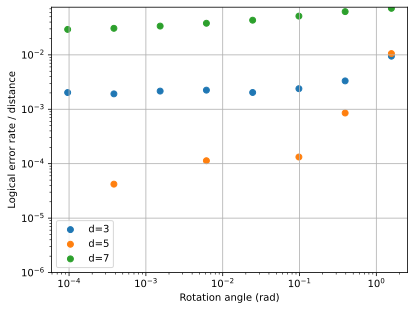

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(thetas_3,error_rates_3, label="d=3")
plt.scatter(thetas_5,error_rates_5, label="d=5")
plt.scatter(thetas_7,error_rates_7, label="d=7")

plt.xscale('log')
plt.xlabel("Rotation angle (rad)")
plt.ylim(bottom=1e-06)
plt.yscale('log')
plt.ylabel("Logical error rate / distance")

plt.grid()
plt.legend()

plt.show()